# 02 · eda

explore the universe + build the label (fund vs its category median over the next 5 days).
run notebook 01 first. ~2k funds so we look at things by category, not one line per fund.

## tl;dr - what the data says

- **~1480 us etfs, 10y, ~33 categories** after dropping leveraged/inverse, broken series (bad ticks),
  and delisted/dead funds (financedatabase still lists ~380 etfs that stopped trading, e.g. ACTV).
- **coverage:** half the funds have the full 10y, a quarter have < ~6.5y. newer funds are just NaN
  before they launched (the panel is ~17% NaN - all pre-launch, expected).
- **label ~51% neutral / 24% over / 24% under** at the 50 bps threshold - but that split is *totally
  different by asset class*: **bonds ~77% neutral** (they barely leave their peers), **sector-equity
  ~25% neutral** (they swing). the model is really solving a different problem per group.
- **balance moves with the market:** neutral drops to ~44% in volatile years (2020, 2022), ~58% in calm
  ones (2017, 2019).
- **signal is nonlinear** (see nb03 decile plots): no feature separates direction *linearly* (best ~0.04
  std), but bucketed, momentum is V-shaped (both tails outperform) and vol/rsi are monotonic. so this
  wants **tree/boosting models, not plain logistic regression**.
- **⚠️ leakage risk:** the label is a forward 5-day return measured daily, so consecutive days overlap
  (lag-1 autocorr ~0.75). the modeling side must use purged/embargoed walk-forward CV or scores will lie.

In [35]:
import yaml, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200, 'display.max_columns', 30)

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW  = ROOT / cfg['paths']['raw']
prices   = pd.read_parquet(RAW / 'prices.parquet')
metadata = pd.read_parquet(RAW / 'metadata.parquet')
prices.index.name = 'date'; prices.columns.name = 'ticker'

# drop leveraged/inverse etfs and broken price series before analysis
bad = pd.Series(False, index=metadata.index)
if cfg.get('exclude_leveraged') and 'is_leveraged' in metadata.columns:
    bad |= metadata['is_leveraged'].fillna(False)
if 'bad_ticks' in metadata.columns:
    bad |= metadata['bad_ticks'].fillna(False)
if cfg.get('exclude_delisted') and 'is_delisted' in metadata.columns:
    bad |= metadata['is_delisted'].fillna(False)
prices = prices.drop(columns=[c for c in metadata.index[bad] if c in prices.columns])
print('dropped', int(bad.sum()), 'funds (leveraged + bad ticks + delisted) |', prices.shape[1], 'left,', metadata['category'].nunique(), 'categories')

dropped 558 funds (leveraged + bad ticks + delisted) | 1479 left, 41 categories


### heads up: the early years are empty on purpose

with a 10y window most etfs are NaN before they launched (~2015+), so the *top* of the price
panel looks all-null. thats expected, not a bug. the labels we save at the end drop those rows.
here's a clean recent slice so you can see real data:

In [36]:
naf = prices.isna().mean().mean() * 100
print(f'{naf:.0f}% of the panel is NaN - all pre-launch rows. per-fund history below in \"history coverage\".')
prices.tail(4).iloc[:, :8]

10% of the panel is NaN - all pre-launch rows. per-fund history below in "history coverage".


ticker,AAA,AAAU,AADR,AAXJ,ABCS,ABEQ,ACES,ACVF
date,,,,,,,,
2026-07-02,24.948000,40.630001,82.480003,113.940002,34.103001,37.827999,34.130001,53.816002
2026-07-06,25.037001,41.040001,84.169998,117.570000,34.098000,37.664001,34.959999,54.122002
2026-07-07,25.031000,40.570000,83.000000,114.250000,34.187000,37.768002,33.279999,53.779999
2026-07-08,25.010000,40.240002,83.089996,115.209999,33.716000,37.273998,33.259998,53.673000


## what got cleaned out

before any analysis we drop three kinds of junk (all configurable in `config.yaml`). the biggest
chunk is **delisted funds** - dead etfs financedatabase still lists whose price just stops (e.g. ACTV
delisted oct-2025). turning `exclude_delisted` off keeps them (less survivorship bias, messier data).

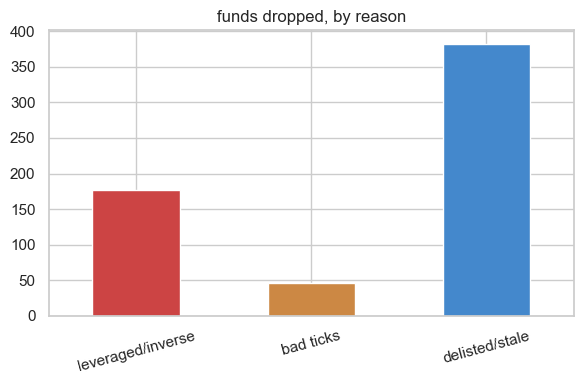

leveraged/inverse    177
bad ticks             47
delisted/stale       382
dtype: int64

In [37]:
raw_md = pd.read_parquet(RAW / 'metadata.parquet')
reasons = pd.Series({
    'leveraged/inverse': int(raw_md.get('is_leveraged', pd.Series(dtype=bool)).sum()),
    'bad ticks':         int(raw_md.get('bad_ticks', pd.Series(dtype=bool)).sum()),
    'delisted/stale':    int(raw_md.get('is_delisted', pd.Series(dtype=bool)).sum()),
})
ax = reasons.plot.bar(figsize=(6, 4), color=['#c44','#c84','#48c'])
ax.set_title('funds dropped, by reason'); ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
reasons

## universe overview

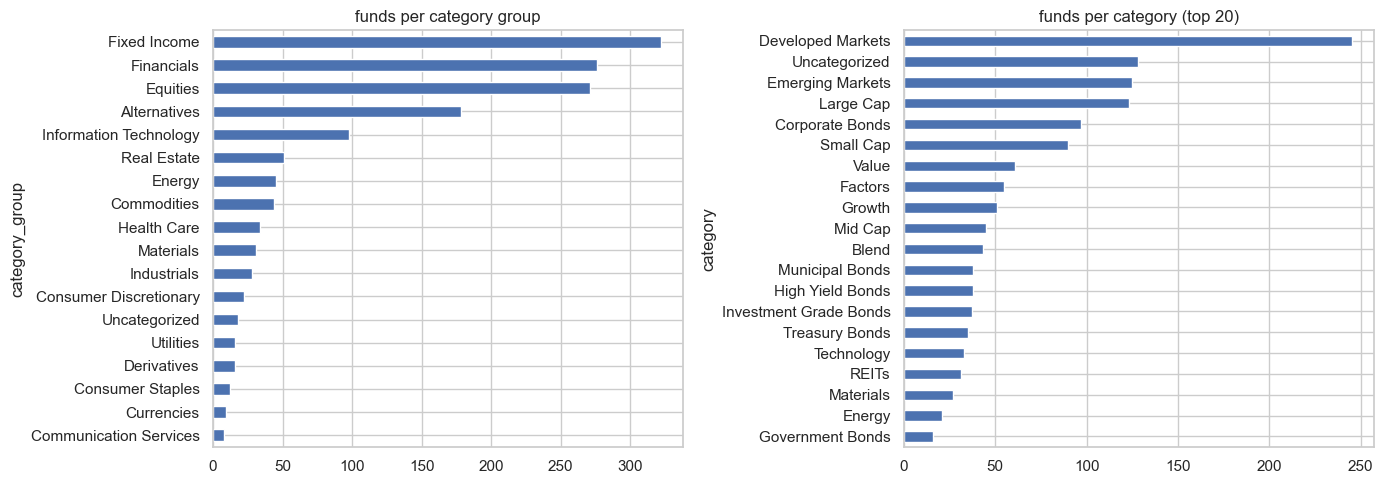

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
metadata['category_group'].reindex(prices.columns).value_counts().plot.barh(ax=ax[0]); ax[0].invert_yaxis(); ax[0].set_title('funds per category group')
metadata['category'].reindex(prices.columns).value_counts().head(20).plot.barh(ax=ax[1]); ax[1].invert_yaxis(); ax[1].set_title('funds per category (top 20)')
plt.tight_layout(); plt.show()

### how the universe grew + what's in it

active funds climb as etfs launch (and dip where they delist). launches peaked mid-cycle; almost
everything is usd.

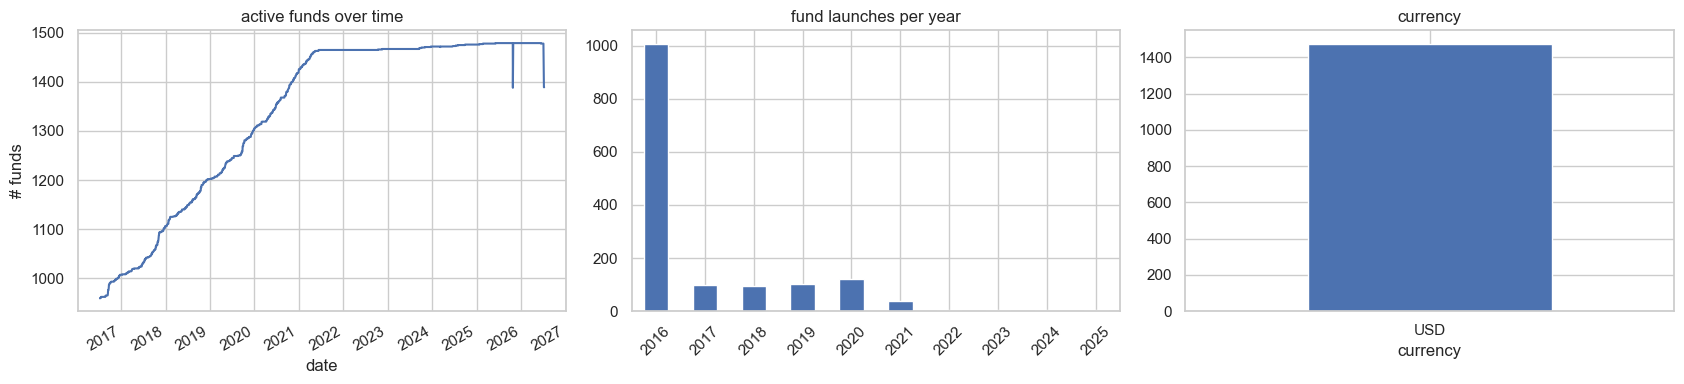

In [39]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
prices.notna().sum(axis=1).plot(ax=ax[0]); ax[0].set_title('active funds over time'); ax[0].set_ylabel('# funds')
launch = prices.apply(lambda s: s.first_valid_index()).dropna()
launch.dt.year.value_counts().sort_index().plot.bar(ax=ax[1]); ax[1].set_title('fund launches per year'); ax[1].tick_params(axis='x', rotation=45)
metadata['currency'].reindex(prices.columns).value_counts().plot.bar(ax=ax[2]); ax[2].set_title('currency'); ax[2].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## history coverage

how much history does each fund actually have? most etfs are way younger than our 10y window,
so they're just empty (NaN) before they launched. thats why the raw price panel / early label
rows look 'all null' - its not a bug, those funds didnt exist yet. we drop the empty rows when
we save the labels below.

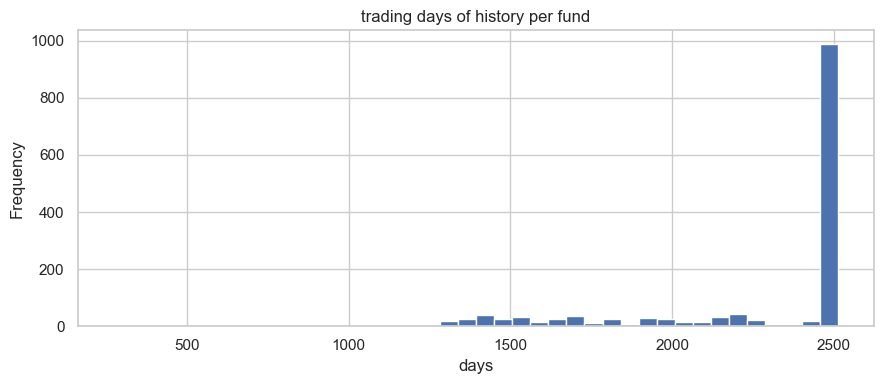

count    1479.0
mean     2271.0
std       405.0
min       274.0
25%      2130.0
50%      2512.0
75%      2512.0
max      2512.0
dtype: float64

In [40]:
cover = prices.notna().sum()
ax = cover.plot.hist(bins=40, figsize=(9, 4)); ax.set_title('trading days of history per fund'); ax.set_xlabel('days')
plt.tight_layout(); plt.show()
cover.describe().round(0)

## prices & returns

what the funds actually did. composites = cross-sectional mean daily return per category group,
cumulated into a $1 index.

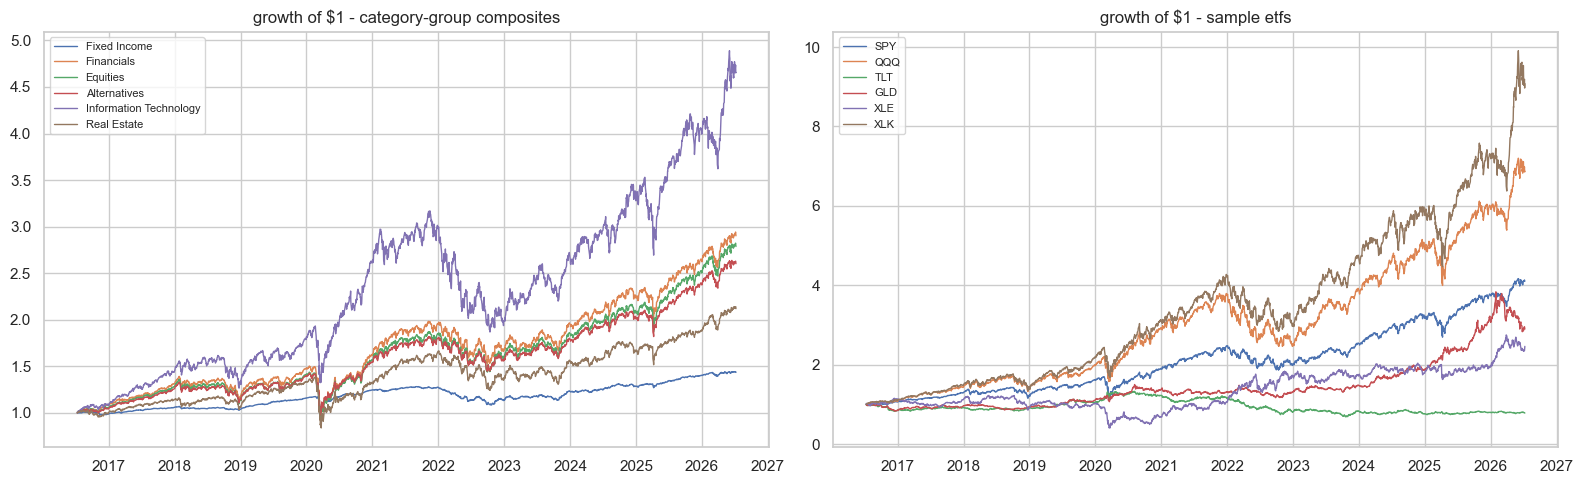

In [41]:
ret = prices.pct_change(fill_method=None)
grp_all = metadata['category_group'].reindex(prices.columns)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for g in grp_all.value_counts().head(6).index:
    cg = grp_all[grp_all == g].index
    comp = (1 + ret[cg].mean(axis=1).fillna(0)).cumprod()
    ax[0].plot(comp.index, comp.values, lw=1, label=g)
ax[0].set_title('growth of $1 - category-group composites'); ax[0].legend(fontsize=8)
for t in [x for x in ['SPY','QQQ','TLT','GLD','XLE','XLK'] if x in prices.columns]:
    s = prices[t].dropna(); ax[1].plot(s.index, s / s.iloc[0], lw=1, label=t)
ax[1].set_title('growth of $1 - sample etfs'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### return / risk distributions across funds

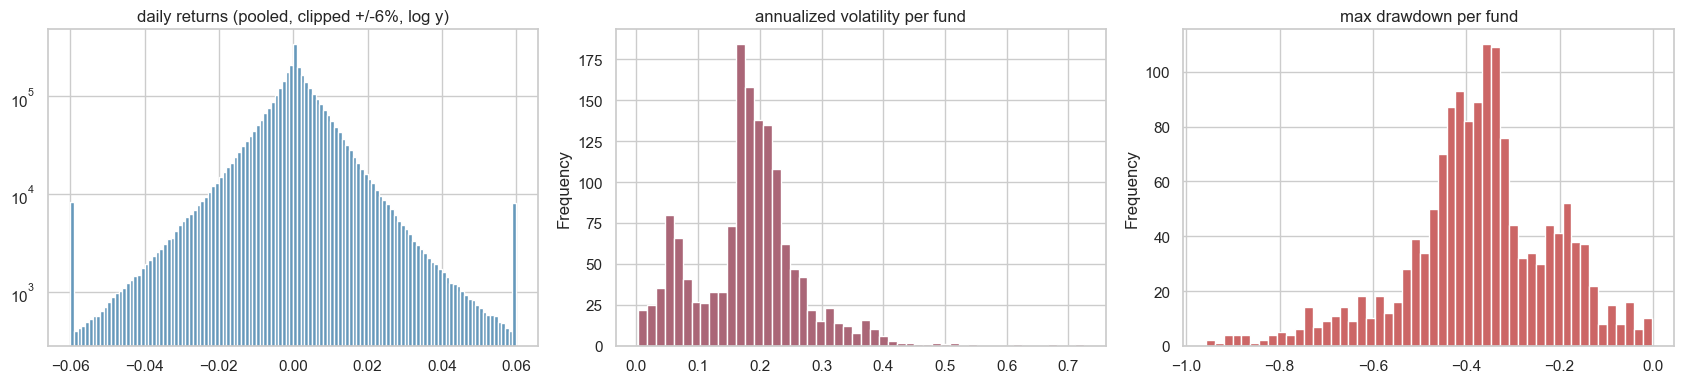

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
dr = ret.values.ravel(); dr = dr[~np.isnan(dr)]
ax[0].hist(np.clip(dr, -0.06, 0.06), bins=120, color='#69b'); ax[0].set_yscale('log')
ax[0].set_title('daily returns (pooled, clipped +/-6%, log y)')
(ret.std() * np.sqrt(252)).dropna().plot.hist(bins=50, ax=ax[1], color='#a67'); ax[1].set_title('annualized volatility per fund')
(prices / prices.cummax() - 1).min().dropna().plot.hist(bins=50, ax=ax[2], color='#c66'); ax[2].set_title('max drawdown per fund')
plt.tight_layout(); plt.show()

### risk vs return by asset class

each fund's annualized return vs its vol, over its own life. tech/sector funds sit high on both,
bonds low on both - the classic risk/return spread.

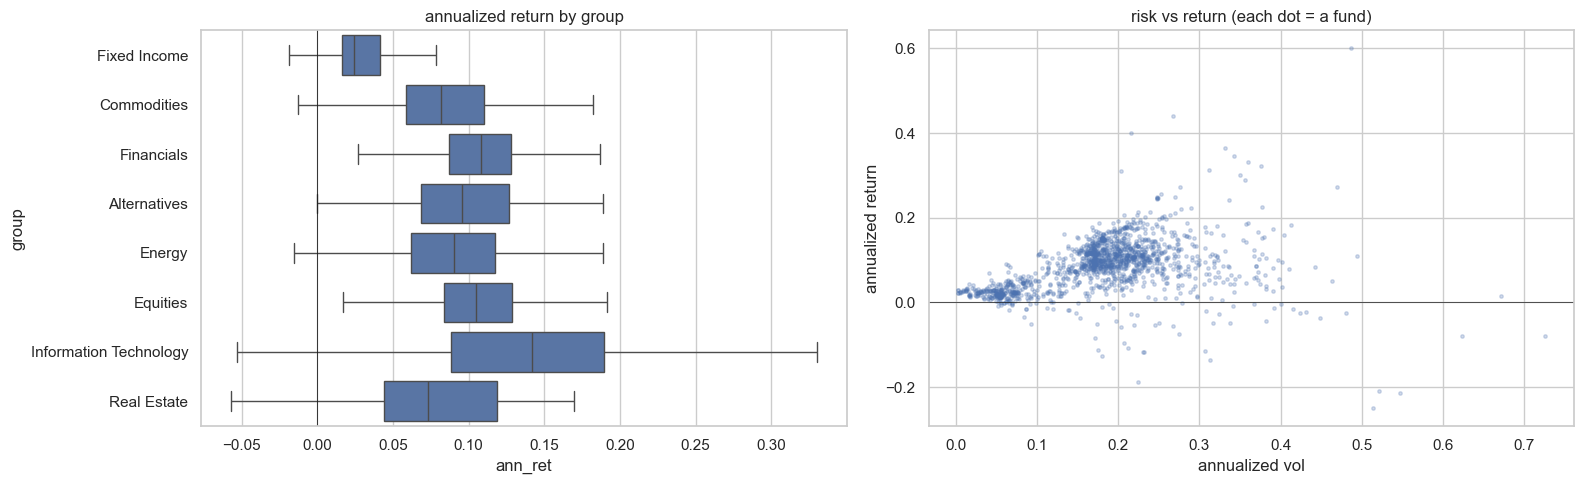

In [43]:
n = prices.notna().sum()
ann_ret = (prices.ffill().iloc[-1] / prices.bfill().iloc[0]) ** (252 / n) - 1
ann_vol = ret.std() * np.sqrt(252)
rr = pd.DataFrame({'ann_ret': ann_ret, 'ann_vol': ann_vol, 'group': grp_all}).dropna()
rr = rr[(rr['ann_vol'] < 1.5) & (rr['ann_ret'].between(-0.5, 1.5))]      # trim short-history outliers for display
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
big_g = rr['group'].value_counts().head(8).index
sns.boxplot(data=rr[rr['group'].isin(big_g)], y='group', x='ann_ret', ax=ax[0], showfliers=False)
ax[0].set_title('annualized return by group'); ax[0].axvline(0, color='k', lw=.6)
ax[1].scatter(rr['ann_vol'], rr['ann_ret'], s=6, alpha=.25); ax[1].set_title('risk vs return (each dot = a fund)')
ax[1].set_xlabel('annualized vol'); ax[1].set_ylabel('annualized return'); ax[1].axhline(0, color='k', lw=.5)
plt.tight_layout(); plt.show()

## the label

`rel = fund_fwd_5d_return - category_median_fwd_5d_return`, bucketed by +/- threshold.
we only label funds whose category has at least `min_group` members (else the 'median' is meaningless).

In [44]:
lcfg = cfg['labels']; h, thr, min_group = lcfg['horizon'], lcfg['threshold'], lcfg['min_group']
cat = metadata['category'].reindex(prices.columns)

# only keep funds in real categories big enough to have a meaningful median
counts = cat.value_counts()
big = counts[(counts >= min_group) & (counts.index != 'Uncategorized')].index
cols = cat[cat.isin(big)].index
px = prices[cols]; cat = cat[cols]

fwd = px.shift(-h) / px - 1.0                              # forward h-day return
cat_med = fwd.T.groupby(cat).transform('median').T         # category median, broadcast to members
rel = fwd - cat_med

label = pd.DataFrame(np.where(rel > thr, 'Outperform',
                     np.where(rel < -thr, 'Underperform', 'Neutral')),
                     index=rel.index, columns=rel.columns).where(rel.notna())
balance = pd.Series(label.values.ravel()).value_counts()
print(f'labelling {len(cols)} funds in {len(big)} categories | threshold {thr} ({thr*1e4:.0f} bps)')
balance

labelling 1342 funds in 33 categories | threshold 0.005 (50 bps)


Neutral         1607285
Outperform       732562
Underperform     730540
Name: count, dtype: int64

### tune the threshold

spread is way bigger than the old index-fund set, so the threshold needs to be bigger too.
pick one that gives a balance you like:

In [45]:
relf = rel.stack().dropna()
print('rel std:', round(relf.std()*1e4, 1), 'bps | abs median:', round(relf.abs().median()*1e4, 1), 'bps')
rows = []
for t in [0.001, 0.002, 0.003, 0.005, 0.0075, 0.01, 0.02]:
    up = (relf > t).mean()*100; dn = (relf < -t).mean()*100
    rows.append({'threshold_bps': t*1e4, 'Under_%': round(dn,1), 'Neutral_%': round(100-up-dn,1), 'Over_%': round(up,1)})
pd.DataFrame(rows)

rel std: 161.1 bps | abs median: 46.1 bps


,threshold_bps,Under_%,Neutral_%,Over_%
0,10.0,41.2,17.5,41.2
1,20.0,35.4,29.2,35.4
2,30.0,30.7,38.5,30.8
3,50.0,23.8,52.3,23.9
4,75.0,17.9,64.2,17.9
5,100.0,13.8,72.5,13.8
6,200.0,5.7,88.6,5.7


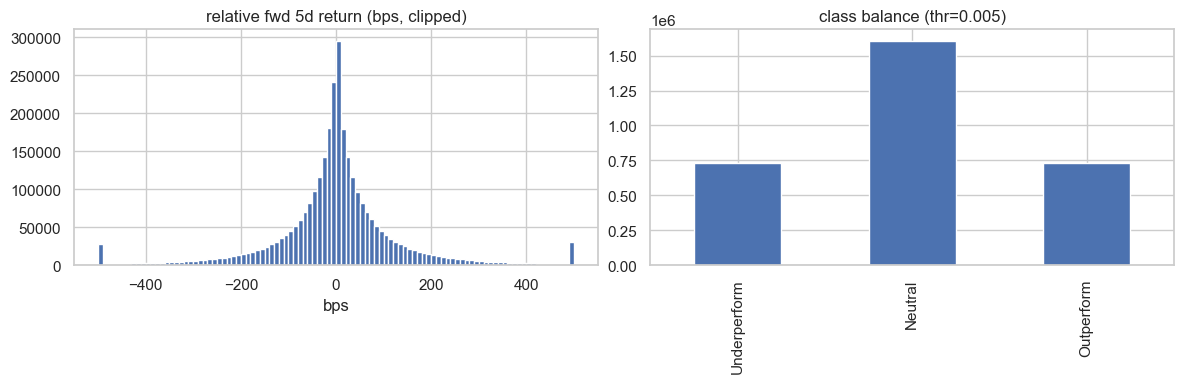

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
(relf.clip(-0.05, 0.05)*1e4).hist(bins=100, ax=ax[0]); ax[0].set_title('relative fwd 5d return (bps, clipped)'); ax[0].set_xlabel('bps')
balance.reindex(['Underperform','Neutral','Outperform']).plot.bar(ax=ax[1]); ax[1].set_title(f'class balance (thr={thr})')
plt.tight_layout(); plt.show()

### dispersion differs a lot by asset class

bond etfs barely move off their peers; sector-equity funds swing hard. so 'beating peers' is a
different-sized bet per group - one global threshold hits each group differently.

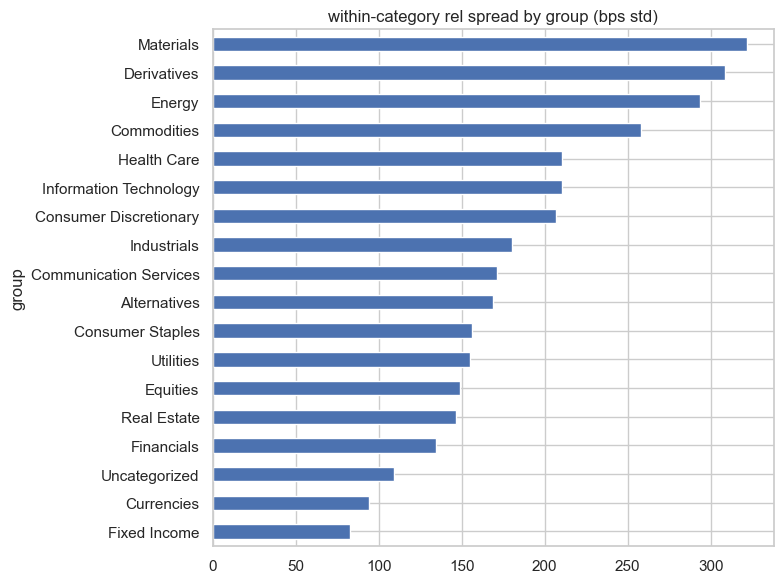

In [47]:
grp = metadata['category_group'].reindex(rel.columns)
disp = rel.stack().rename('rel').reset_index()
disp['group'] = disp['ticker'].map(grp)
by_grp = disp.groupby('group')['rel'].std().mul(1e4).sort_values(ascending=False)
ax = by_grp.plot.barh(figsize=(8, 6)); ax.invert_yaxis(); ax.set_title('within-category rel spread by group (bps std)')
plt.tight_layout(); plt.show()

### ... which means the class balance is per-asset-class

**biggest takeaway of the notebook:** bonds sit on their peer median almost always (~77% neutral),
sector-equity funds diverge constantly (~25% neutral). a model will find 'beat your peers' easy to
call in fixed income and hard in sectors - worth stratifying metrics by group later.

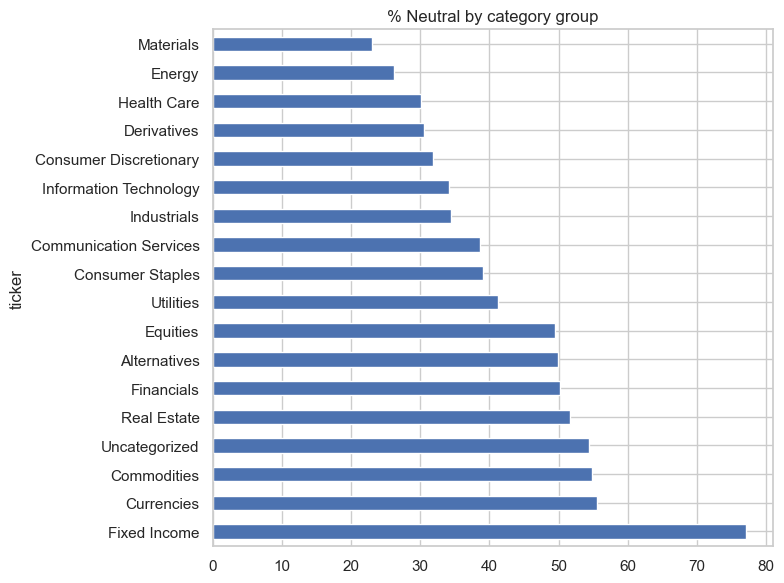

ticker
Materials                 23.0
Energy                    26.0
Health Care               30.0
Derivatives               31.0
Consumer Discretionary    32.0
Information Technology    34.0
Industrials               34.0
Communication Services    39.0
Consumer Staples          39.0
Utilities                 41.0
Equities                  50.0
Alternatives              50.0
Financials                50.0
Real Estate               52.0
Uncategorized             54.0
Commodities               55.0
Currencies                55.0
Fixed Income              77.0
dtype: float64

In [48]:
ll = label.stack(); ll.index.names = ['date', 'ticker']
tick = ll.index.get_level_values('ticker')
neu_by = ll.eq('Neutral').groupby(tick.map(metadata['category_group'])).mean().mul(100).sort_values()
ax = neu_by.plot.barh(figsize=(8, 6)); ax.set_title('% Neutral by category group'); ax.invert_yaxis()
plt.tight_layout(); plt.show()
neu_by.round(0)

### ⚠️ the labels overlap - modeling must use purged/embargoed CV

the label is a *forward 5-day* return measured every day, so two consecutive days share 4 of their 5
future days. that makes the daily label strongly autocorrelated - a random shuffle *or* a plain time
split will leak the future into training and inflate the scores. use purged + embargoed walk-forward
CV (or sample every 5th day). this is the one thing that'll silently break the modeling if ignored.

In [49]:
ac = rel.corrwith(rel.shift(1)).median()
print(f'median lag-1 autocorrelation of daily rel: {ac:.2f}  (~0 = independent days, high = heavy overlap)')

median lag-1 autocorrelation of daily rel: 0.76  (~0 = independent days, high = heavy overlap)


### class balance moves with the market

calm years -> most funds hug their peers (more neutral); volatile years (2020, 2022) -> they scatter
(less neutral). so train and test have to be different time periods, never shuffled.

In [50]:
yr = ll.index.get_level_values('date').year
by_year = pd.DataFrame({'labelled_rows': ll.groupby(yr).size(),
                        'pct_neutral': ll.eq('Neutral').groupby(yr).mean().mul(100).round(0)})
by_year

,labelled_rows,pct_neutral
date,,
2016,111734,55.0
2017,243080,60.0
2018,269330,53.0
2019,289775,60.0
2020,314591,45.0
2021,334700,53.0
2022,335136,46.0
2023,334172,53.0
2024,337739,53.0


### more label views

threshold sweep as a picture, the raw (not-relative) forward return, how rel spreads per group,
and how the class mix shifts year to year.

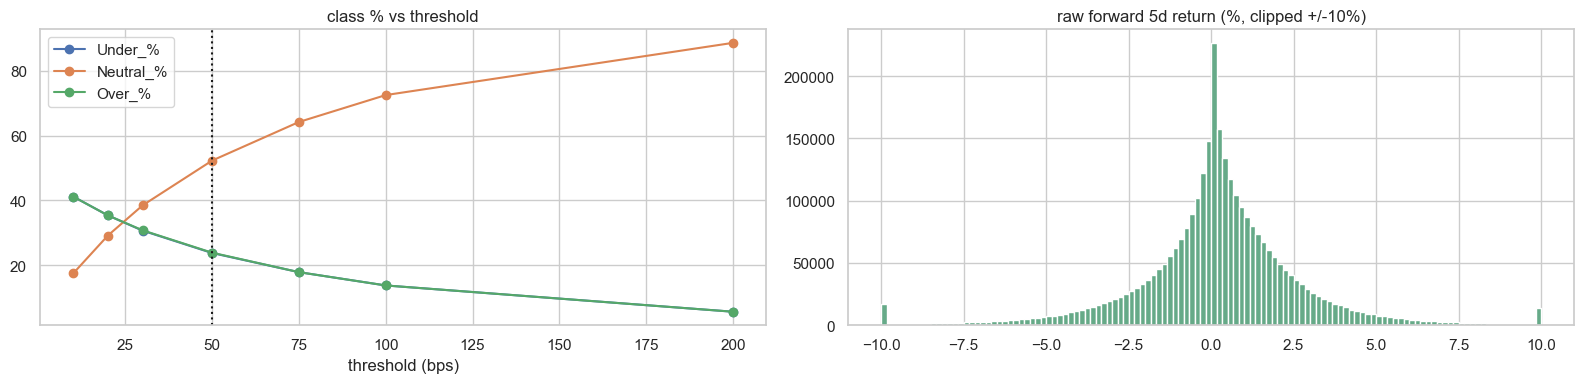

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
pd.DataFrame(rows).set_index('threshold_bps').plot(ax=ax[0], marker='o')
ax[0].set_title('class % vs threshold'); ax[0].set_xlabel('threshold (bps)'); ax[0].axvline(thr*1e4, color='k', ls=':')
fr = fwd.stack(future_stack=True).dropna()
ax[1].hist(fr.clip(-0.1, 0.1) * 100, bins=120, color='#6a8'); ax[1].set_title('raw forward 5d return (%, clipped +/-10%)')
plt.tight_layout(); plt.show()

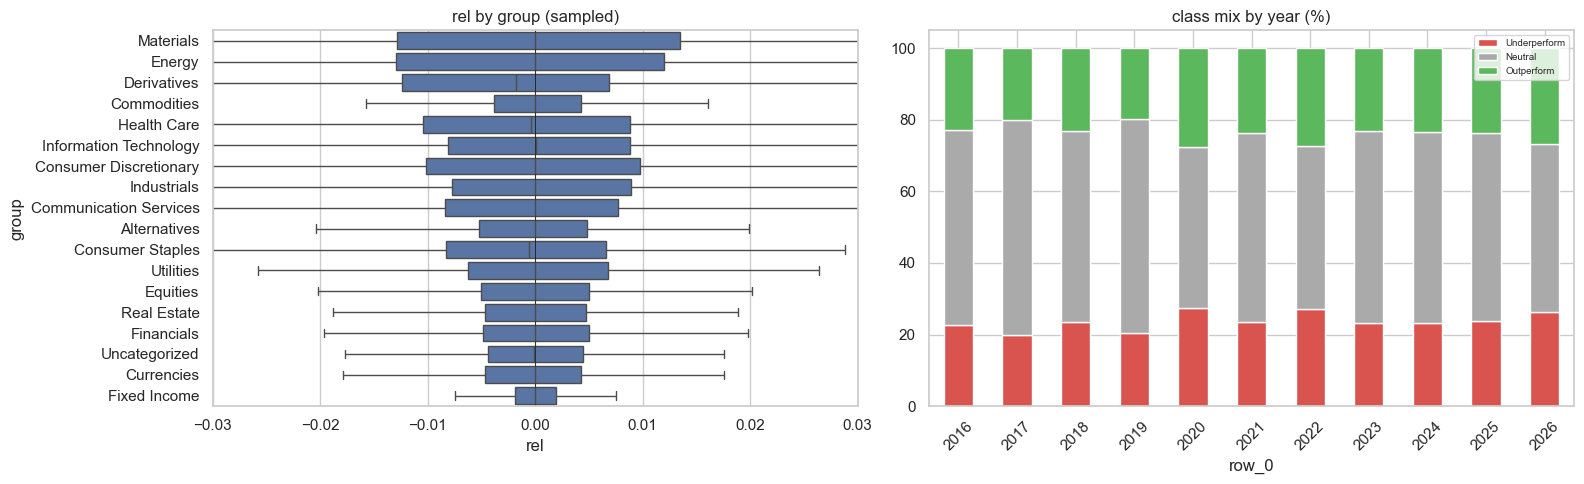

In [52]:
rl = rel.stack().dropna().rename('rel').reset_index()
rl['group'] = rl['ticker'].map(metadata['category_group'])
samp = rl.sample(min(200000, len(rl)), random_state=0)
order_g = samp.groupby('group')['rel'].std().sort_values(ascending=False).index
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=samp, y='group', x='rel', order=order_g, ax=ax[0], showfliers=False)
ax[0].set_xlim(-0.03, 0.03); ax[0].axvline(0, color='k', lw=.6); ax[0].set_title('rel by group (sampled)')
mix = pd.crosstab(ll.index.get_level_values('date').year, ll)
mix = mix.div(mix.sum(axis=1), axis=0).mul(100)[['Underperform','Neutral','Outperform']]
mix.plot.bar(stacked=True, ax=ax[1], color=['#d9534f','#aaaaaa','#5cb85c'])
ax[1].set_title('class mix by year (%)'); ax[1].legend(fontsize=7); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## save labels

long table for whoever does modeling next. we only keep rows that actually have a label -
a (date, fund) pair is null when the fund didnt exist yet (big deal with 15y history: newer
etfs are blank for years) or in the last 5 days (no future price). so we drop those here,
every saved row is a real observation.

In [53]:
def stk(df):
    s = df.stack(future_stack=True); s.index.names = ['date','ticker']; return s

labels_long = pd.concat({'fwd_ret': stk(fwd), 'cat_median': stk(cat_med),
                         'rel': stk(rel), 'label': stk(label)}, axis=1)
labels_long = labels_long.dropna(subset=['label'])          # <- drops the empty early rows
labels_long['category'] = labels_long.index.get_level_values('ticker').map(metadata['category'])
PROC = ROOT / cfg['paths']['processed']; PROC.mkdir(parents=True, exist_ok=True)
labels_long.to_parquet(PROC / 'labels.parquet')
print('saved', labels_long.shape, '- every row is a real observation')
labels_long.head()

saved (3070387, 5) - every row is a real observation


fwd_ret  cat_median       rel       label          category
date       ticker                                                              
2016-07-11 AADR    0.033605    0.027319  0.006286  Outperform  Emerging Markets
           AAXJ    0.029014    0.027319  0.001695     Neutral  Emerging Markets
           ACWF    0.042185    0.015150  0.027035  Outperform             Blend
           ACWI    0.016505    0.015150  0.001355     Neutral             Blend
           ACWX    0.021634    0.015150  0.006484  Outperform             Blend